In [1]:
import helpers
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from scipy.linalg import qr
import pickle
from tqdm import tqdm
import random
from helpers import saveObj, readObj
from collections import defaultdict

BAD = ['VT', 'VFb', 'VFt'] # KIS,S
project_dir = r'C:\Users\jodge\Documents\School\Summer24\tinymlcontest2022_demo_example'
dir_path = r'C:\Users\jodge\Documents\School\Summer24\tinyml_contest_data_training'
directory_files = os.listdir(dir_path)

training_script = os.path.join(project_dir, 'training_save_deep_models.py')
testing_script = os.path.join(project_dir, 'testing_performances.py')
models_dir = os.path.join(project_dir, 'models')
results_dir = os.path.join(project_dir, 'results')

"""
Energy captured: ranks needed
 5%: 14  10%: 29  15%: 46  20%: 64   25%:  84
30%: 106 35%: 129 40%: 154 45%: 182  50%:  215
55%: 252 60%: 297 65%: 354 70%: 443  75%:  552
80%: 670 85%: 798 90%: 935 95%: 1084 100%: 1250 
"""

'\nEnergy captured: ranks needed\n 5%: 14  10%: 29  15%: 46  20%: 64   25%:  84\n30%: 106 35%: 129 40%: 154 45%: 182  50%:  215\n55%: 252 60%: 297 65%: 354 70%: 443  75%:  552\n80%: 670 85%: 798 90%: 935 95%: 1084 100%: 1250 \n'

In [2]:
data_indices_dir = r'..\tinymlcontest2022_demo_example\data_indices'
files = os.listdir(data_indices_dir)
train_idx_path = os.path.join(data_indices_dir, files[1])
train_idx_path

'..\\tinymlcontest2022_demo_example\\data_indices\\train_indice.csv'

In [3]:
df_train_indices = pd.read_csv(train_idx_path, sep=",", header=0)
train_names = df_train_indices.Filename.to_list()

label_list = pd.read_csv(r'..\tinymlcontest2022_demo_example\\label_list.csv', sep=",", header=0)
label_list = label_list.labels.to_list()

train_names[:5], label_list

(['S66-VT-114.txt',
  'S66-VT-115.txt',
  'S66-VT-116.txt',
  'S66-VT-117.txt',
  'S66-VT-118.txt'],
 ['AFb', 'AFt', 'SR', 'SVT', 'VFb', 'VFt', 'VPD', 'VT'])

# Generate full 8 classes indices

In [4]:
label_list = pd.read_csv(r'..\tinymlcontest2022_demo_example\\label_list.csv', sep=",", header=0)
label_list = label_list.labels.to_list()

for idx_file in files:
    counts = defaultdict(int)
    idx_path = os.path.join(data_indices_dir, idx_file)
    df_indices = pd.read_csv(idx_path, sep=",", header=0)
    names = df_indices.Filename.to_list()

    print(idx_file, len(names))
    
    fns = []
    labs = []
    for filename in tqdm(names):
        parts = filename.split('-')
        #pn = parts[0][1:] #patient number
        label = parts[1]
        counts[label] += 1 
        new_label = label_list.index(label)
        fns.append(filename)
        labs.append(new_label)
    df = pd.DataFrame({
        'label': labs,
        'Filename': fns
    })
    print(idx_file, counts)
    output_folder = r'..\\tinymlcontest2022_demo_example\\multi_indices\\'
    output_name = idx_file
    output_path = os.path.join(output_folder, output_name)
    #df.to_csv(output_path, index=None)

test_indice.csv 5625


100%|█████████████████████████████████████████████████████████████████████████| 5625/5625 [00:00<00:00, 1410134.48it/s]


test_indice.csv defaultdict(<class 'int'>, {'SR': 2640, 'SVT': 129, 'VFb': 289, 'VT': 2005, 'VFt': 95, 'AFb': 309, 'VPD': 158})
train_indice.csv 24588


100%|███████████████████████████████████████████████████████████████████████| 24588/24588 [00:00<00:00, 1369709.62it/s]

train_indice.csv defaultdict(<class 'int'>, {'VT': 10692, 'SR': 10033, 'AFb': 765, 'SVT': 815, 'AFt': 343, 'VFb': 974, 'VFt': 171, 'VPD': 795})


## Generate Full Multiclass WITHOUT SR or VT

In [7]:
label_list = pd.read_csv(r'..\tinymlcontest2022_demo_example\\label_list.csv', sep=",", header=0)
label_list = label_list.labels.to_list().copy()
label_list.remove('SR')
label_list.remove('VT')
print(label_list)

for idx_file in files:
    counts = defaultdict(int)
    idx_path = os.path.join(data_indices_dir, idx_file)
    df_indices = pd.read_csv(idx_path, sep=",", header=0)
    names = df_indices.Filename.to_list()

    #print(idx_file, len(names))
    
    fns = []
    labs = []
    for filename in tqdm(names):
        parts = filename.split('-')
        #pn = parts[0][1:] #patient number
        label = parts[1]
        if label == 'SR' or label == 'VT':
            continue
        counts[label] += 1 
        new_label = label_list.index(label)
        fns.append(filename)
        labs.append(new_label)
    df = pd.DataFrame({
        'label': labs,
        'Filename': fns
    })
    print(idx_file, counts)
    output_folder = r'..\\tinymlcontest2022_demo_example\\multi_minor_indices\\'
    output_name = idx_file
    output_path = os.path.join(output_folder, output_name)
    df.to_csv(output_path, index=None)

['AFb', 'AFt', 'SVT', 'VFb', 'VFt', 'VPD']


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5625/5625 [00:00<?, ?it/s]


test_indice.csv defaultdict(<class 'int'>, {'SVT': 129, 'VFb': 289, 'VFt': 95, 'AFb': 309, 'VPD': 158})


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 24588/24588 [00:00<00:00, 1573704.04it/s]

train_indice.csv defaultdict(<class 'int'>, {'AFb': 765, 'SVT': 815, 'AFt': 343, 'VFb': 974, 'VFt': 171, 'VPD': 795})


### Verify That Training Patients != Testing Patients

In [11]:
patients_in_training = set()
patients_in_testing = set()
for idx_file in files:
    print(idx_file)
    idx_path = os.path.join(data_indices_dir, idx_file)
    df_indices = pd.read_csv(idx_path, sep=",", header=0)
    names = df_indices.Filename.to_list()

    for fi in names:
        parts = fi.split('-')
        pn = parts[0][1:] #patient number
        label = parts[1]
        if 'test' in idx_file:
            patients_in_testing.add(pn)
        else:
            patients_in_training.add(pn)
print(patients_in_testing, patients_in_training, patients_in_testing.intersection(patients_in_training))

test_indice.csv
train_indice.csv
{'09', '51', '21', '19', '75', '41', '82', '01', '27', '48', '02', '68', '76', '12', '70', '18'} {'81', '44', '94', '49', '46', '16', '69', '45', '60', '17', '66', '31', '85', '20', '30', '04', '13', '72', '58', '56', '65', '15', '37', '79', '95', '93', '28', '06', '91', '05', '88', '80', '24', '59', '57', '89', '50', '73', '32', '23', '74', '07', '64', '53', '62', '25', '08', '29', '71', '43', '90', '40', '77', '26', '10', '34', '86', '63', '36', '35'} set()


## https://github.com/Zhoushanglin100/TinyML-HuskyCSDeepical/blob/main/ModelDesign/dataset.py DATA AUGMENTATION

In [108]:
def scaling(X, sigma=0.1):
    scalingFactor = np.random.normal(loc=1.0, scale=sigma, size=(1, X.shape[1])) # X.shape scaling (1, 1250, 1)
    myNoise = np.matmul(np.ones((X.shape[0], 1)), scalingFactor).reshape(1, -1, 1)
    return X * myNoise

def verflip(sig):
    return np.flip(sig) # [::-1, :]

def shift(sig):
    for col in range(sig.shape[1]):
        # offset = np.random.choice(range(-interval, interval))
        offset = random.gauss(0, 0.05) # original range (0,1)
        sig[:, col] += offset
    return sig
    
def selectWindow(sig, length=500):
    """ my version, wrong shapes on return
    original_length = X.shape[1]
    rand_start = random.randint(0, len(sig) - length)
    return sig[rand_start: rand_end + length]
    """
    # Claude 3.5 Sonnet
    sig_1d = sig.squeeze()
    original_length = sig_1d.shape[0]
        
    # Ensure length doesn't exceed signal
    length = min(length, original_length)
        
    # Random start index
    rand_start = random.randint(0, original_length - length)
    
    # Extract window
    windowed_sig_1d = sig_1d[rand_start:rand_start + length]
    
    # Reshape back to original 2D shape
    return windowed_sig_1d.reshape(1, length, 1)

In [109]:
for i in range(5):
    signal, fi = helpers.getRandomAlignedSignal((i+1)%2)
    
    fix, axs = plt.subplots(1,4, figsize=(16,4), dpi=1200)
    style = helpers.getStyle(fi)
    #print(signal.shape)
    signal = signal.reshape(1, len(signal), 1)
    
    axs[0].plot(signal.squeeze(), style)
    axs[0].set_title(f'Original: {fi}')

    axs[1].plot(scaling(signal).squeeze(), style)
    axs[1].set_title(f'"Scaling" aka Noise')

    axs[2].plot(verflip(signal).squeeze(), style)
    axs[2].set_title(f'VerFlip')

    axs[3].plot(shift(signal).squeeze(), style)
    axs[3].set_title(f'Shift')
    
    plt.show()

# New Training and Testing Split

In [ ]:
label_list = pd.read_csv(r'..\tinymlcontest2022_demo_example\\label_list.csv', sep=",", header=0)
label_list = label_list.labels.to_list()

test_pns = None    # the original test set of patient numbers
train_pns = None   # the original train set of patient numbers

for idx_file in files:
    print(idx_file)
    holder = defaultdict(set)
                        
    idx_path = os.path.join(data_indices_dir, idx_file)
    df_indices = pd.read_csv(idx_path, sep=",", header=0)
    names = df_indices.Filename.to_list()
    
    for filename in tqdm(names):
        parts = filename.split('-')
        pn = parts[0][1:] #patient number
        label = parts[1]
        holder[pn].add(label)

    if not test_pns:
        test_pns = holder.copy()
    else:
        train_pns = holder.copy()
#print(test_pns)
#print(train_pns)

In [7]:
trainKeys = set(train_pns.keys())
testKeys  = set(test_pns.keys())
allKeys = trainKeys.union(testKeys)

print(len(trainKeys), "patients in training")
print(len(testKeys), "patients in testing")
print("The intersection of the patient sets for training and testing is...", testKeys.intersection(trainKeys))
"Conclusion: The training and testing sets contain entirely different patients."

60 patients in training
16 patients in testing
The intersection of the patient sets for training and testing is... set()


'Conclusion: The training and testing sets contain entirely different patients.'

# ChatGPT Attempt

In [5]:
from collections import defaultdict
from collections import Counter
import random
import numpy as np

In [45]:
# Initialize a dictionary to hold patient files
patient_files = defaultdict(list)

# Group files by patient
for filename in directory_files:
    parts = filename.split('-')
    pn = parts[0][1:]  # patient number (assuming patient ID starts with some prefix)
    patient_files[pn].append(filename)


# Initialize a dictionary to hold label counts per patient
patient_labels = {}

for pn, files in patient_files.items():
    labels = [f.split('-')[1] for f in files]  # extract labels for all files of the patient
    label_counts = Counter(labels)
    patient_labels[pn] = label_counts

### keep randomly selecting until each set has all 8 categories

### this next cell should return a viable set of patients for testing and training such that each set contains all eight labels. the cell below it should be run in tandem after visually inspecting for comparison to the original test set so we can save the list permanently

In [16]:
overall_label_counts = Counter([f.split('-')[1] for f in directory_files])
total_files = sum(list(overall_label_counts.values()))
overall_label_ratios = {label: count / total_files * 100 for label, count in overall_label_counts.items()}

def evaluate_split(patient_set):
    label_counts = Counter()
    for pn in patient_set:
        label_counts.update(patient_labels[pn])
    total = sum(label_counts.values())
    label_ratios = {label: count / total * 100 for label, count in label_counts.items()}
    return label_ratios
    
def randomSelect(showOriginal = False):
    # Now, stratify the patients into train and test sets
    train_patients = []
    test_patients = []
    
    # Randomly sample 16 patients for the test set
    rand_number_of_patients = random.randint(15,17)
    #print(rand_number_of_patients)
    test_patient_sample = random.sample(list(patient_labels.keys()), rand_number_of_patients)
    if showOriginal:
        test_patient_sample = patients_in_testing
    
    # Assign patients to test set first
    for pn in test_patient_sample:
        test_patients.append(pn)
    train_patients = [pn for pn in patient_labels.keys() if pn not in test_patients]
    # Evaluate training and test splits
    train_label_ratios = evaluate_split(train_patients)
    test_label_ratios = evaluate_split(test_patients)

    if showOriginal:
        test_label_ratios['AFt'] = 0
    #print(train_label_ratios,test_label_ratios)

    if len(test_label_ratios) == len(train_label_ratios) == 8:
        labels = sorted(overall_label_ratios.keys())

        # Construct the DataFrame from sorted keys
        dfTEMP = pd.DataFrame({
            'Label': labels,
            'Overall': [overall_label_ratios[label] for label in labels],
            'Train': [train_label_ratios[label] for label in labels],
            'Test': [test_label_ratios[label] for label in labels]
        })
        #print("\n",dfTEMP)
        return dfTEMP, test_patients, train_patients
    else:
        return randomSelect()
        
angry, test_patients, train_patients = randomSelect(showOriginal=False)
print(f"Test Patients:\t{len(test_patients)}\nTrain Patients:\t{len(train_patients)}\n")

num_test = 0
for pat in test_patients:
    for lab, val in patient_labels[pat].items():

        num_test += val
num_train = 0
for pat in train_patients:
    for lab, val in patient_labels[pat].items():

        num_train += val
        
print(f"Files in Test:\t{num_test}/5625\t{num_test/5625}\nFiles in Train:\t{num_train}/24588\t{num_train/24588}")
angry

Test Patients:	15
Train Patients:	61

Files in Test:	6590/5625
Files in Train:	23623/24588


,Label,Overall,Train,Test
0,AFb,3.554761,3.382297,4.172989
1,AFt,1.135273,1.282648,0.606980
2,SR,41.945520,42.166533,41.153263
3,SVT,3.124483,3.373831,2.230653
4,VFb,4.180320,4.152733,4.279211
5,VFt,0.880416,0.723871,1.441578
6,VPD,3.154271,3.365364,2.397572
7,VT,42.024956,41.552724,43.717754


In [15]:
BAD = ['VT', 'VFb', 'VFt']
#patients_in_training = set()
#patients_in_testing = set()

In [19]:
pkl_test = "data/test_patients.pkl"
pkl_train = "data/train_patients.pkl"

saveObj(test_patients,pkl_test)
saveObj(train_patients,pkl_train)

saving to data/test_patients.pkl
saving to data/train_patients.pkl


In [22]:
verify_test = readObj(pkl_test)
verify_train = readObj(pkl_train)
#print(verify_test, verify_train)

reading from data/test_patients.pkl
reading from data/train_patients.pkl


# Balanced Sampling

In [60]:
test_counts = None
train_counts = None
for idx_file in os.listdir(data_indices_dir):
    counts = defaultdict(int)
    idx_path = os.path.join(data_indices_dir, idx_file)
    df_indices = pd.read_csv(idx_path, sep=",", header=0)
    names = df_indices.Filename.to_list()
    
    fns = []
    labs = []
    for filename in tqdm(names):
        parts = filename.split('-')
        #pn = parts[0][1:] #patient number
        label = parts[1]
        counts[label] += 1
    if 'test' in idx_file:
        test_counts = counts.copy()
    else:
        train_counts = counts.copy()
    print(idx_file, len(names), counts)

for key, value in test_counts.items():
    print(f"{key}: {value + train_counts[key]}")

100%|█████████████████████████████████████████████████████████████████████████| 5625/5625 [00:00<00:00, 1406435.77it/s]


test_indice.csv 5625 defaultdict(<class 'int'>, {'SR': 2640, 'SVT': 129, 'VFb': 289, 'VT': 2005, 'VFt': 95, 'AFb': 309, 'VPD': 158})


100%|███████████████████████████████████████████████████████████████████████| 24588/24588 [00:00<00:00, 2049189.24it/s]

train_indice.csv 24588 defaultdict(<class 'int'>, {'VT': 10692, 'SR': 10033, 'AFb': 765, 'SVT': 815, 'AFt': 343, 'VFb': 974, 'VFt': 171, 'VPD': 795})
SR: 12673
SVT: 944
VFb: 1263
VT: 12697
VFt: 266
AFb: 1074
VPD: 953


Arbitrary decision, we'll only keep 10% of SR and VT.

In [68]:
chance_to_keep = 0.10 
categories_to_cut = ['SR', 'VT']
balanced_indices_dir = 'balanced_indices/'

for idx_file in os.listdir(data_indices_dir):
    idx_path = os.path.join(data_indices_dir, idx_file)
    print("processing",idx_path)
    df_indices = pd.read_csv(idx_path, sep=",", header=0)
    names = df_indices.Filename.to_list()
    
    mask = df_indices.Filename.str.split('-').str[1].isin(categories_to_cut)
    random_nums = np.random.random(len(df_indices))
    keep_mask = ~(mask & (random_nums > chance_to_keep))
    df_indices = df_indices[keep_mask].reset_index(drop=True)
    output_path = os.path.join(balanced_indices_dir, idx_file)
    df_indices.to_csv(output_path, index=None)
print(f"Processing complete, {chance_to_keep * 100}% of {categories_to_cut} kept.\n")
### VERIFICATION
for idx_file in os.listdir(balanced_indices_dir):
    counts = defaultdict(int)
    idx_path = os.path.join(balanced_indices_dir, idx_file)
    #print("verifying",idx_path)
    df_indices = pd.read_csv(idx_path, sep=",", header=0)
    names = df_indices.Filename.to_list()
    
    fns = []
    labs = []
    for filename in names:
        parts = filename.split('-')
        #pn = parts[0][1:] #patient number
        label = parts[1]
        counts[label] += 1
    out_of = out_of = sum(train_counts.values())
    if 'test' in idx_file:
        out_of = sum(test_counts.values())
    
    print(f"{len(names)} / {out_of} files kept, {counts}")

processing ..\tinymlcontest2022_demo_example\data_indices\test_indice.csv
processing ..\tinymlcontest2022_demo_example\data_indices\train_indice.csv
Processing complete, 10.0% of ['SR', 'VT'] kept.

1431 / 5625 files kept, defaultdict(<class 'int'>, {'SR': 248, 'SVT': 129, 'VFb': 289, 'VT': 203, 'VFt': 95, 'AFb': 309, 'VPD': 158})
5966 / 24588 files kept, defaultdict(<class 'int'>, {'VT': 1083, 'SR': 1020, 'AFb': 765, 'SVT': 815, 'AFt': 343, 'VFb': 974, 'VFt': 171, 'VPD': 795})


## Make the new indices with optional multiclass

In [23]:
def createIndiceFiles(test_patients, train_patients, multiclass=True):
    test_tuples = []
    train_tuples = []  
    for filename in tqdm(directory_files):
        parts = filename.split('-')
        pn = parts[0][1:] #patient number
        label = parts[1]
        if multiclass:
            label = label_list.index(label)
        else:
            label = 1 if label in BAD else 0
        
        if pn in test_patients:
            test_tuples.append((label,filename))
        else:
            train_tuples.append((label,filename))
    
    columns = ['label','Filename']
    print(f"len test {len(test_tuples)} len train {len(train_tuples)}")
    test_table = pd.DataFrame(test_tuples,columns=columns)
    train_table = pd.DataFrame(train_tuples,columns=columns)
    
    output_folder = r'..\\tinymlcontest2022_demo_example\\multi_indices_new\\'
    if not multiclass:
        output_folder = r'..\\tinymlcontest2022_demo_example\\indices_new\\'
    
    output_name_test = "test_indice.csv"
    output_name_train = "train_indice.csv"
    
    output_path_test = os.path.join(output_folder, output_name_test)
    output_path_train = os.path.join(output_folder, output_name_train)
    
    test_table.to_csv(output_path_test, index=None)
    train_table.to_csv(output_path_train, index=None)

createIndiceFiles(verify_test, verify_train)

100%|███████████████████████████████████████████████████████████████████████| 30213/30213 [00:00<00:00, 1262276.94it/s]

len test 6590 len train 23623


In [24]:
print(verify_test, verify_train)

sum = 0
for pn in verify_test:
    for label, count in patient_labels[pn].items():
        sum += count

sum

['31', '02', '07', '15', '50', '51', '62', '24', '68', '70', '73', '75', '37', '41', '20'] ['01', '04', '05', '06', '08', '09', '10', '12', '13', '16', '17', '18', '19', '21', '23', '25', '26', '27', '28', '29', '30', '32', '34', '35', '36', '40', '43', '44', '45', '46', '48', '49', '53', '56', '57', '58', '59', '60', '63', '64', '65', '66', '69', '71', '72', '74', '76', '77', '79', '80', '81', '82', '85', '86', '88', '89', '90', '91', '93', '94', '95']


6590

# Just focusing on SR and VT - maybe more classes later

In [30]:
#patients_in_testing, patients_in_training
wanted_classes = ['SR', 'VT']
output_directory = r'twoclass_indices'
print("wanted:", wanted_classes)

for fi in files: # indices files
    #print(fi)
    file_path = os.path.join(data_indices_dir, fi)
    print("reading", file_path)

    df = pd.read_csv(file_path)
    before = len(df.Filename)
    df = df[df.Filename.str.split('-').str[1].isin(wanted_classes)]
    #print(df.head())
    after = len(df.Filename)
    print(f"{before - after} other classes removed")

    output_path = os.path.join(output_directory, fi)
    
    df.to_csv(output_path, index=None)
    print(output_path, "saved\n")

wanted: ['SR', 'VT']
reading ..\tinymlcontest2022_demo_example\data_indices\test_indice.csv
980 other classes removed
twoclass_indices\test_indice.csv saved

reading ..\tinymlcontest2022_demo_example\data_indices\train_indice.csv
3863 other classes removed
twoclass_indices\train_indice.csv saved



## Three Classes: SR, VT, Other

In [44]:
# SR, VT, Other Classes
#patients_in_testing, patients_in_training
wanted_classes = {
    'SR':0,
    'VT':1
}
def get_label(wanted):
    return wanted_classes.get(wanted,2)
    
output_directory = r'threeclass_indices'
print("wanted:", wanted_classes)

for fi in files: # indices files
    #print(fi)
    file_path = os.path.join(data_indices_dir, fi)
    print("reading", file_path)

    df = pd.read_csv(file_path)
    #print(df)
    before = len(df.Filename)
    df['label'] = df['Filename'].str.split('-').str[1].map(get_label)
    print(df)
    after = len(df.Filename)
    print(f"{before - after} other classes removed")

    output_path = os.path.join(output_directory, fi)
    
    df.to_csv(output_path, index=None)
    print(output_path, "saved\n")

wanted: {'SR': 0, 'VT': 1}
reading ..\tinymlcontest2022_demo_example\data_indices\test_indice.csv
      label         Filename
0         0     S27-SR-1.txt
1         0     S27-SR-2.txt
2         0     S27-SR-3.txt
3         0     S27-SR-4.txt
4         0     S27-SR-5.txt
...     ...              ...
5620      2  S01-AFb-166.txt
5621      2  S01-AFb-167.txt
5622      2  S01-AFb-168.txt
5623      2  S01-AFb-169.txt
5624      2  S01-AFb-170.txt

[5625 rows x 2 columns]
0 other classes removed
threeclass_indices\test_indice.csv saved

reading ..\tinymlcontest2022_demo_example\data_indices\train_indice.csv
       label        Filename
0          1  S66-VT-114.txt
1          1  S66-VT-115.txt
2          1  S66-VT-116.txt
3          1  S66-VT-117.txt
4          1  S66-VT-118.txt
...      ...             ...
24583      0  S80-SR-138.txt
24584      0  S80-SR-139.txt
24585      0  S80-SR-140.txt
24586      0  S80-SR-141.txt
24587      0  S80-SR-142.txt

[24588 rows x 2 columns]
0 other classes r

## FFT Functions

Files Processing:   0%|                                                                      | 0/30213 [00:00<?, ?it/s]

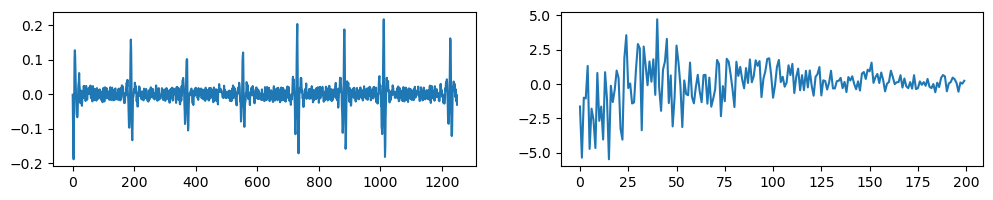

Files Processing:   0%|                                                            | 1/30213 [00:00<1:18:50,  6.39it/s]

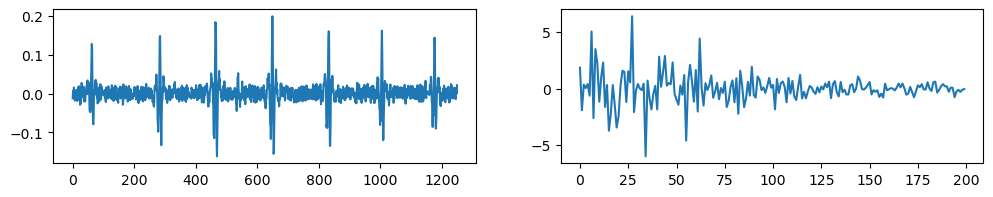

Files Processing: 100%|████████████████████████████████████████████████████████| 30213/30213 [00:13<00:00, 2215.52it/s]

DONE


In [36]:
def fftSparseGen(mask, trunc = False, inverse = False):
    limit = 2
    for fi in tqdm(directory_files, desc="Files Processing"):
        temp = np.loadtxt(os.path.join(dir_path,fi))
        fft = np.fft.rfft(temp)
        
        if trunc:
            done = fft[:][mask]
        else: # zeroes otherwise
            done = np.where(mask, fft, 0) 
        #print(len(done))
        if inverse:
            done = np.fft.irfft(done)
        if limit > 0:
            fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,2))
            ax1.plot(temp)
            ax2.plot(done)
            plt.show()
            limit -= 1
        
        outName = os.path.join(r'..\fft_data', fi)
        #print(outName)
        #np.savetxt(outName, done.real, fmt='%.7f')
    
    print("DONE")

bandpass_mask = np.zeros(626, dtype=bool)
pass_band_filter = list(range(15*5,55*5))
bandpass_mask[pass_band_filter] = True

fftSparseGen(bandpass_mask, trunc = True)